# 🔄 Basic Agent Workflows with Microsoft Foundry (Python)

## 📋 Workflow Orchestration Tutorial

This notebook introduces the **Workflow Builder** capabilities of the Microsoft Agent Framework using **Azure AI Foundry Agents** as the backend.

## 🎯 What We Build

A two-agent travel recommendation workflow:

```
[User prompt]
    → FrontDesk   (travel agent recommends one activity)
    → Concierge   (reviews for authenticity / local experience)
```

## ⚙️ Prerequisites

### Environment variables (`.env`)
```env
AZURE_AI_PROJECT_ENDPOINT=https://<your-project>.services.ai.azure.com/api/projects/<project-id>
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4.1
```

### Authentication
```bash
az login
```

In [1]:
# ! pip install -r ../../../Installation/requirements.txt -U

In [2]:
import os
from typing import cast

from azure.identity.aio import AzureCliCredential
from dotenv import load_dotenv

from agent_framework.azure import AzureAIAgentsProvider
from agent_framework import (
    AgentExecutor,
    AgentResponse,
    WorkflowBuilder,
    WorkflowEvent,
    WorkflowViz,
)

In [3]:
load_dotenv()

True

In [4]:
REVIEWER_NAME = "Concierge"
REVIEWER_INSTRUCTIONS = """
You are a hotel concierge who has opinions about providing the most local and authentic experiences for travelers.
The goal is to determine if the front desk travel agent has recommended the best non-touristy experience for a traveler.
If so, state that it is approved.
If not, provide insight on how to refine the recommendation without using a specific example.
"""

FRONTDESK_NAME = "FrontDesk"
FRONTDESK_INSTRUCTIONS = """
You are a Front Desk Travel Agent with ten years of experience and are known for brevity as you deal with many customers.
The goal is to provide the best activities and locations for a traveler to visit.
Only provide a single recommendation per response.
You're laser focused on the goal at hand.
Don't waste time with chit chat.
Consider suggestions when refining an idea.
"""

Workflow visualization:
flowchart TD
  front_desk_agent["front_desk_agent (Start)"];
  reviewer_agent["reviewer_agent"];
  front_desk_agent --> reviewer_agent;


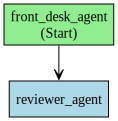

front-desk-agent: Visit the Louvre Museum to see world-renowned art, including the Mona Lisa.

concierge-agent: This recommendation leans heavily toward a touristy experience rather than an authentic or local one. While the Louvre is iconic, it is not ideal for travelers seeking genuine local Parisian life. To refine this suggestion, focus on activities that immerse you in daily routines, cultural traditions, and neighborhoods where locals spend their time, ensuring a truly Parisian experience.

Final state: WorkflowRunState.IDLE
Agents cleaned up.


In [6]:
from IPython.display import SVG, display, HTML

front_desk_agent_obj = None
reviewer_agent_obj = None

async with (
    AzureCliCredential() as credential,
    AzureAIAgentsProvider(credential=credential) as provider,
):
    try:
        # Create agents in Azure AI Foundry
        front_desk_agent_obj = await provider.create_agent(
            name="front-desk-agent",
            instructions=FRONTDESK_INSTRUCTIONS,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        front_desk_agent = AgentExecutor(front_desk_agent_obj, id="front_desk_agent")

        reviewer_agent_obj = await provider.create_agent(
            name="concierge-agent",
            instructions=REVIEWER_INSTRUCTIONS,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        reviewer_agent = AgentExecutor(reviewer_agent_obj, id="reviewer_agent")

        # Build the workflow: FrontDesk → Concierge
        workflow = (
            WorkflowBuilder(start_executor=front_desk_agent)
            .add_edge(front_desk_agent, reviewer_agent)
            .build()
        )

        # Visualize
        print("Workflow visualization:")
        viz = WorkflowViz(workflow)
        print(viz.to_mermaid())
        svg_file = viz.export(format="svg")
        if svg_file and os.path.exists(svg_file):
            try:
                display(SVG(filename=svg_file))
            except Exception:
                with open(svg_file, "r", encoding="utf-8") as f:
                    display(HTML(f.read()))

        # Run the workflow
        events = await workflow.run("I would like to go to Paris.")

        outputs = cast(list[AgentResponse], events.get_outputs())
        for output in outputs:
            print(f"{output.messages[0].author_name}: {output.text}\n")

        print("Final state:", events.get_final_state())

    finally:
        # Clean up agents from Azure AI Foundry
        for agent_obj in [front_desk_agent_obj, reviewer_agent_obj]:
            if agent_obj is not None:
                try:
                    await provider._agents_client.delete_agent(agent_obj.id)
                except Exception:
                    pass
        print("Agents cleaned up.")